# TB-DOTS CAR CDSS — Temporal Treatment Outcome Prediction Model

**Hybrid Bi-LSTM + Masked Attention + Static Feature model** that predicts treatment outcome (**Success / Failure**) with a confidence score, using monthly patient monitoring data and baseline clinical features.

### Progressive Temporal Training
The model is trained on **progressive partial sequences**: for each patient, it learns to predict from M0 alone, M0–M1, M0–M2, ..., up to full M0–M12 data. This:
- Makes the model genuinely temporal — predictions improve as more monthly data becomes available
- Increases effective training samples from 205 to **2,665** (205 patients × 13 months)
- Enables reliable **early warning** at any month during treatment

Designed for use as a **Clinical Decision Support System (CDSS)**.

### Outputs
- Trained model checkpoint → `models/best_model.pt`
- Evaluation metrics → `models/evaluation_report.txt`
- Per-patient predictions → `models/predictions.csv`
- Training curves plot → `models/training_curves.png`
- Per-month performance → `models/per_month_performance.png`

## 0. Imports & Configuration

In [15]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
)

warnings.filterwarnings("ignore")

# ── Reproducibility ─────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Paths ───────────────────────────────────────────────────────
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "dataset" / "temporal" / "output"
MODEL_DIR = BASE_DIR / "models"
MODEL_DIR.mkdir(exist_ok=True)

print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}")
print(f"Data   : {DATA_DIR}")
print(f"Models : {MODEL_DIR}")

Device : cpu
PyTorch: 2.10.0+cpu
Data   : c:\Users\Ven\Documents\thesis-2\TB-DOTS-CAR-CDSS\dataset\temporal\output
Models : c:\Users\Ven\Documents\thesis-2\TB-DOTS-CAR-CDSS\models


## 1. Data Loading & Label Creation

Load the preprocessed temporal and static arrays from the preprocessing pipeline. The **outcome** columns are removed from static features to prevent target leakage. Binary labels are created:
- **Success (1)** = Cured, Treatment Completed
- **Failure (0)** = Died, Lost to Follow-Up, Not Evaluated

In [16]:
def load_data():
    """Load preprocessed arrays and create binary outcome labels."""

    # --- Temporal features (already scaled) ----------------------
    X_temporal = np.load(DATA_DIR / "X_temporal.npy")  # (205, 13, 8)

    # --- Static features (already encoded & scaled) --------------
    X_static = np.load(DATA_DIR / "X_static.npy")  # (205, 56)
    feature_names = np.load(DATA_DIR / "feature_names.npz", allow_pickle=True)
    static_names = list(feature_names["static"])

    # --- Identify and REMOVE outcome columns (target leakage) ----
    outcome_cols = [
        "outcome_Cured",
        "outcome_Died",
        "outcome_Lost to Follow-Up",
        "outcome_Not Evaluated",
        "outcome_Treatment Completed",
    ]
    outcome_idx = [static_names.index(c) for c in outcome_cols]
    keep_idx = [i for i in range(X_static.shape[1]) if i not in outcome_idx]

    # Remove outcome columns from static features
    X_static_clean = X_static[:, keep_idx]
    static_names_clean = [static_names[i] for i in keep_idx]

    # --- Build binary labels -------------------------------------
    df = pd.read_csv(DATA_DIR / "cleaned_combined_dataset.csv")
    success_outcomes = {"Cured", "Treatment Completed"}
    y = np.array(
        [1 if o in success_outcomes else 0 for o in df["outcome"]],
        dtype=np.float32,
    )

    print(f"Temporal features : {X_temporal.shape}")
    print(f"Static features   : {X_static_clean.shape}  (outcome cols removed)")
    print(f"Labels            : {y.shape}  "
          f"(Success={int(y.sum())}, Failure={int(len(y) - y.sum())})")

    return X_temporal, X_static_clean, y, static_names_clean

X_temporal, X_static, y, static_names = load_data()

Temporal features : (205, 13, 8)
Static features   : (205, 51)  (outcome cols removed)
Labels            : (205,)  (Success=188, Failure=17)


## 2. Progressive Temporal Dataset & DataLoader

**Key design**: For each patient, we create **13 training samples** — one for each month (M0 through M12). At month `t`, the model only sees months `0..t` (the rest is zero-padded and masked). This:

- Trains the model to predict from **partial sequences** (essential for a CDSS that provides early warnings)
- Increases effective training samples from **205 → 2,665** (helping with the small dataset)
- Ensures **no train/inference mismatch** — the model is trained on exactly the data it will see during real-time CDSS use

**Patient-level splitting** prevents data leakage: we split patients 70/20/10 first, *then* expand into progressive sequences.

In [17]:
class TBProgressiveDataset(Dataset):
    """
    Progressive temporal dataset for CDSS training.

    For each patient, creates one sample per month t (0..max_month):
      - Temporal input: months 0..t (rest zero-padded to 13 steps)
      - Sequence length: t + 1  (how many months are valid)
      - Static features: same across all months
      - Label: final treatment outcome (same across all months)

    This teaches the model to predict from partial sequences,
    which is exactly what a CDSS does in real-time.
    """

    def __init__(self, X_temporal, X_static, y,
                 min_month=0, max_month=12):
        self.X_temporal_list = []
        self.seq_lens = []
        self.X_static_list = []
        self.y_list = []

        for i in range(len(y)):
            for t in range(min_month, max_month + 1):
                # Zero-pad future months
                x_t = np.zeros_like(X_temporal[i])
                x_t[: t + 1] = X_temporal[i, : t + 1]

                self.X_temporal_list.append(x_t)
                self.seq_lens.append(t + 1)
                self.X_static_list.append(X_static[i])
                self.y_list.append(y[i])

        self.X_temporal_arr = np.array(self.X_temporal_list, dtype=np.float32)
        self.seq_lens_arr = np.array(self.seq_lens, dtype=np.int64)
        self.X_static_arr = np.array(self.X_static_list, dtype=np.float32)
        self.y_arr = np.array(self.y_list, dtype=np.float32)

    def __len__(self):
        return len(self.y_arr)

    def __getitem__(self, idx):
        return (
            torch.FloatTensor(self.X_temporal_arr[idx]),
            torch.LongTensor([self.seq_lens_arr[idx]]),
            torch.FloatTensor(self.X_static_arr[idx]),
            torch.FloatTensor([self.y_arr[idx]]),
        )


def build_dataloaders(X_temporal, X_static, y, batch_size=32):
    """
    Split PATIENTS 70/20/10, then expand into progressive sequences.
    Patient-level split prevents data leakage.
    """

    indices = np.arange(len(y))

    # First split: 70% train, 30% temp (by patient index)
    train_idx, rest_idx = train_test_split(
        indices, test_size=0.30, random_state=SEED, stratify=y
    )
    # Second split: 20% val, 10% test
    val_idx, test_idx = train_test_split(
        rest_idx, test_size=1 / 3, random_state=SEED, stratify=y[rest_idx]
    )

    y_train_patients = y[train_idx]
    y_val_patients = y[val_idx]
    y_test_patients = y[test_idx]

    print(f"Patient split:")
    print(f"  Train : {len(train_idx)} patients  "
          f"(S={int(y_train_patients.sum())}, "
          f"F={int(len(y_train_patients) - y_train_patients.sum())})")
    print(f"  Val   : {len(val_idx)} patients  "
          f"(S={int(y_val_patients.sum())}, "
          f"F={int(len(y_val_patients) - y_val_patients.sum())})")
    print(f"  Test  : {len(test_idx)} patients  "
          f"(S={int(y_test_patients.sum())}, "
          f"F={int(len(y_test_patients) - y_test_patients.sum())})")

    # Progressive datasets: train & val use ALL months (M0..M12)
    train_ds = TBProgressiveDataset(
        X_temporal[train_idx], X_static[train_idx], y[train_idx],
        min_month=0, max_month=12,
    )
    val_ds = TBProgressiveDataset(
        X_temporal[val_idx], X_static[val_idx], y[val_idx],
        min_month=0, max_month=12,
    )
    # Test: full sequences only (M12) for final evaluation
    test_ds = TBProgressiveDataset(
        X_temporal[test_idx], X_static[test_idx], y[test_idx],
        min_month=12, max_month=12,
    )

    print(f"\nProgressive samples:")
    print(f"  Train : {len(train_ds)} samples  ({len(train_idx)} patients × 13 months)")
    print(f"  Val   : {len(val_ds)} samples  ({len(val_idx)} patients × 13 months)")
    print(f"  Test  : {len(test_ds)} samples  ({len(test_idx)} patients × 1 full seq)")

    # Weighted random sampler for class imbalance
    class_counts = np.bincount(train_ds.y_arr.astype(int))
    class_weights = 1.0 / class_counts
    sample_weights = np.array(
        [class_weights[int(label)] for label in train_ds.y_arr]
    )
    sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(train_ds),
        replacement=True,
    )

    train_loader = DataLoader(
        train_ds, batch_size=batch_size, sampler=sampler, drop_last=False
    )
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    return (train_loader, val_loader, test_loader,
            y_train_patients, y_test_patients,
            train_idx, val_idx, test_idx)

(train_loader, val_loader, test_loader,
 y_train, y_test,
 train_idx, val_idx, test_idx) = build_dataloaders(
    X_temporal, X_static, y, batch_size=32
)

Patient split:
  Train : 143 patients  (S=131, F=12)
  Val   : 41 patients  (S=38, F=3)
  Test  : 21 patients  (S=19, F=2)

Progressive samples:
  Train : 1859 samples  (143 patients × 13 months)
  Val   : 533 samples  (41 patients × 13 months)
  Test  : 21 samples  (21 patients × 1 full seq)


## 3. Model Architecture

**Hybrid Bi-LSTM + Masked Attention + Static FC** architecture:

| Branch | Description |
|--------|------------|
| **Temporal** | Bidirectional LSTM (2 layers) with **packed sequences** → Masked Soft Attention (attends only to valid months) → LayerNorm |
| **Static** | FC(51→64) → BN → ReLU → Dropout → FC(64→32) → BN → ReLU |
| **Fusion** | Concatenate temporal context + static repr → FC → Sigmoid |

The model accepts a `seq_lens` parameter indicating how many months (1–13) are valid for each sample. This enables training on progressive partial sequences and proper CDSS early warning at any month.

In [18]:
class TemporalAttention(nn.Module):
    """Soft attention over LSTM time-step outputs with optional masking."""

    def __init__(self, hidden_size):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.Tanh(),
            nn.Linear(hidden_size // 2, 1, bias=False),
        )

    def forward(self, lstm_out, seq_lens=None):
        # lstm_out: (batch, seq_len, hidden_size)
        scores = self.attn(lstm_out).squeeze(-1)           # (batch, seq_len)

        # Mask future (zero-padded) months so attention ignores them
        if seq_lens is not None:
            max_len = lstm_out.size(1)
            # mask[b, t] = True if t >= seq_lens[b]  (i.e., invalid)
            time_idx = torch.arange(max_len, device=lstm_out.device).unsqueeze(0)
            mask = time_idx >= seq_lens.unsqueeze(1)       # (batch, seq_len)
            scores = scores.masked_fill(mask, float("-inf"))

        weights = torch.softmax(scores, dim=1)             # (batch, seq_len)
        context = torch.bmm(weights.unsqueeze(1),
                            lstm_out).squeeze(1)           # (batch, hidden_size)
        return context, weights


class TB_LSTM_CDSS(nn.Module):
    """
    Hybrid model for TB treatment outcome prediction.

    Temporal branch : Bidirectional LSTM (packed sequences) + Masked Attention
    Static branch   : Feed-forward network
    Fusion          : Concatenate → FC → Sigmoid

    Accepts `seq_lens` so it can be trained on progressive
    partial sequences and used as a real-time CDSS.
    """

    def __init__(
        self,
        temporal_features: int = 8,
        static_features: int = 51,
        lstm_hidden: int = 64,
        lstm_layers: int = 2,
        dropout: float = 0.3,
    ):
        super().__init__()

        # ── Temporal branch ──────────────────────────────────────
        self.lstm = nn.LSTM(
            input_size=temporal_features,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0.0,
        )
        self.temporal_attention = TemporalAttention(lstm_hidden * 2)
        self.temporal_norm = nn.LayerNorm(lstm_hidden * 2)

        # ── Static branch ────────────────────────────────────────
        self.static_net = nn.Sequential(
            nn.Linear(static_features, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        # ── Fusion + classifier ──────────────────────────────────
        fusion_dim = lstm_hidden * 2 + 32
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def forward(self, x_temporal, x_static, seq_lens=None):
        # ── Temporal: pack → LSTM → unpack → masked attention ──
        if seq_lens is not None:
            packed = nn.utils.rnn.pack_padded_sequence(
                x_temporal,
                seq_lens.cpu().clamp(min=1),
                batch_first=True,
                enforce_sorted=False,
            )
            packed_out, _ = self.lstm(packed)
            lstm_out, _ = nn.utils.rnn.pad_packed_sequence(
                packed_out, batch_first=True,
                total_length=x_temporal.size(1),
            )
        else:
            lstm_out, _ = self.lstm(x_temporal)

        context, attn_weights = self.temporal_attention(lstm_out, seq_lens)
        context = self.temporal_norm(context)               # (B, H*2)

        # ── Static ───────────────────────────────────────────────
        static_repr = self.static_net(x_static)            # (B, 32)

        # ── Fuse ─────────────────────────────────────────────────
        fused = torch.cat([context, static_repr], dim=1)   # (B, H*2+32)
        logit = self.classifier(fused).squeeze(-1)         # (B,)
        return logit, attn_weights

### Initialize Model

In [19]:
model = TB_LSTM_CDSS(
    temporal_features=X_temporal.shape[2],  # 8
    static_features=X_static.shape[1],      # 51
    lstm_hidden=64,
    lstm_layers=2,
    dropout=0.3,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parameters: {total_params:,} total, {trainable:,} trainable")
print(f"\n{model}")

Parameters: 163,937 total, 163,937 trainable

TB_LSTM_CDSS(
  (lstm): LSTM(8, 64, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (temporal_attention): TemporalAttention(
    (attn): Sequential(
      (0): Linear(in_features=128, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=1, bias=False)
    )
  )
  (temporal_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (static_net): Sequential(
    (0): Linear(in_features=51, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=160, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e

## 4. Training

Training uses:
- **BCEWithLogitsLoss** with `pos_weight` to handle class imbalance
- **AdamW** optimizer with weight decay
- **ReduceLROnPlateau** scheduler
- **Early stopping** (patience=20)
- **Gradient clipping** (max_norm=1.0)

In [20]:
def train_model(
    model, train_loader, val_loader, y_train,
    epochs=150, lr=1e-3, patience=20,
):
    """Train with class-weighted BCE, early stopping, and LR scheduling.

    Handles progressive temporal batches: (x_temporal, seq_lens, x_static, labels).
    """

    # Class weight for loss function
    n_pos = y_train.sum()
    n_neg = len(y_train) - n_pos
    pos_weight = torch.tensor([n_neg / n_pos], device=DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=7, min_lr=1e-6
    )

    best_val_loss = float("inf")
    best_epoch = 0
    no_improve = 0
    history = {"train_loss": [], "val_loss": [], "val_auc": []}

    for epoch in range(1, epochs + 1):
        # ── Train ────────────────────────────────────────────────
        model.train()
        train_losses = []
        for x_t, seq_len, x_s, labels in train_loader:
            x_t = x_t.to(DEVICE)
            seq_len = seq_len.squeeze(-1).to(DEVICE)  # (B,)
            x_s = x_s.to(DEVICE)
            labels = labels.squeeze(-1).to(DEVICE)    # (B,)

            optimizer.zero_grad()
            logits, _ = model(x_t, x_s, seq_lens=seq_len)
            loss = criterion(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_losses.append(loss.item())

        # ── Validate ─────────────────────────────────────────────
        model.eval()
        val_losses, val_probs, val_labels = [], [], []
        with torch.no_grad():
            for x_t, seq_len, x_s, labels in val_loader:
                x_t = x_t.to(DEVICE)
                seq_len = seq_len.squeeze(-1).to(DEVICE)
                x_s = x_s.to(DEVICE)
                labels = labels.squeeze(-1).to(DEVICE)

                logits, _ = model(x_t, x_s, seq_lens=seq_len)
                loss = criterion(logits, labels)
                val_losses.append(loss.item())
                val_probs.extend(torch.sigmoid(logits).cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        avg_train = np.mean(train_losses)
        avg_val = np.mean(val_losses)
        val_probs_arr = np.array(val_probs)
        val_labels_arr = np.array(val_labels)

        try:
            val_auc = roc_auc_score(val_labels_arr, val_probs_arr)
        except ValueError:
            val_auc = 0.5

        history["train_loss"].append(avg_train)
        history["val_loss"].append(avg_val)
        history["val_auc"].append(val_auc)

        scheduler.step(avg_val)

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:>3d}/{epochs}  "
                  f"Train Loss={avg_train:.4f}  "
                  f"Val Loss={avg_val:.4f}  "
                  f"Val AUC={val_auc:.4f}")

        # ── Early stopping ───────────────────────────────────────
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            best_epoch = epoch
            no_improve = 0
            torch.save(model.state_dict(), MODEL_DIR / "best_model.pt")
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"\nEarly stopping at epoch {epoch} "
                      f"(best epoch: {best_epoch}, val_loss: {best_val_loss:.4f})")
                break

    # Reload best weights
    model.load_state_dict(torch.load(MODEL_DIR / "best_model.pt",
                                     map_location=DEVICE, weights_only=True))
    return model, history

model, history = train_model(
    model, train_loader, val_loader, y_train,
    epochs=150, lr=1e-3, patience=20,
)

Epoch   1/150  Train Loss=0.1824  Val Loss=1.4409  Val AUC=0.9574
Epoch  10/150  Train Loss=0.0149  Val Loss=0.5550  Val AUC=0.6911
Epoch  20/150  Train Loss=0.0070  Val Loss=0.7377  Val AUC=0.6554
Epoch  30/150  Train Loss=0.0040  Val Loss=0.2813  Val AUC=0.7191
Epoch  40/150  Train Loss=0.0047  Val Loss=0.8295  Val AUC=0.6636
Epoch  50/150  Train Loss=0.0116  Val Loss=0.4868  Val AUC=0.7487

Early stopping at epoch 54 (best epoch: 34, val_loss: 0.2785)


### Training Curves

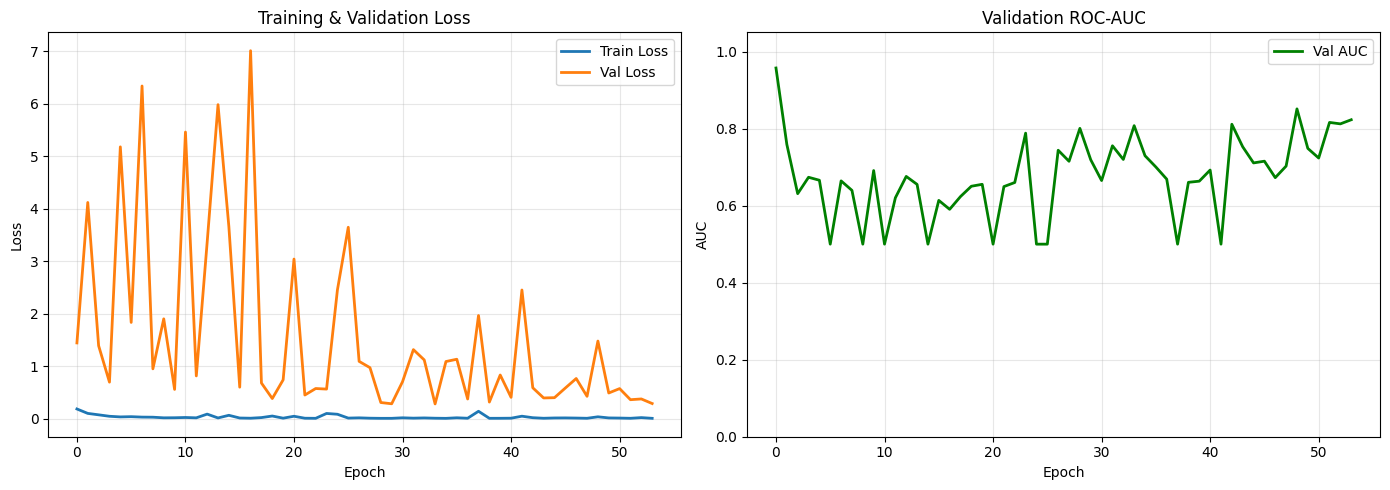

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history["train_loss"], label="Train Loss", linewidth=2)
ax1.plot(history["val_loss"], label="Val Loss", linewidth=2)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Training & Validation Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history["val_auc"], label="Val AUC", color="green", linewidth=2)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("AUC")
ax2.set_title("Validation ROC-AUC")
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig(MODEL_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Evaluation on Test Set

Evaluate the best model on the held-out **10% test set** with full classification metrics.

In [22]:
def evaluate_model(model, test_loader):
    """Full evaluation on held-out test set (full sequences)."""
    model.eval()
    all_probs, all_labels, all_attns = [], [], []

    with torch.no_grad():
        for x_t, seq_len, x_s, labels in test_loader:
            x_t = x_t.to(DEVICE)
            seq_len = seq_len.squeeze(-1).to(DEVICE)
            x_s = x_s.to(DEVICE)

            logits, attn_w = model(x_t, x_s, seq_lens=seq_len)
            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.squeeze(-1).numpy())
            all_attns.extend(attn_w.cpu().numpy())

    probs = np.array(all_probs)
    labels = np.array(all_labels)
    attns = np.array(all_attns)
    preds = (probs >= 0.5).astype(int)

    # ── Metrics ──────────────────────────────────────────────────
    metrics = {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
        "specificity": recall_score(labels, preds, pos_label=0, zero_division=0),
    }

    try:
        metrics["roc_auc"] = roc_auc_score(labels, probs)
    except ValueError:
        metrics["roc_auc"] = float("nan")

    try:
        metrics["pr_auc"] = average_precision_score(labels, probs)
    except ValueError:
        metrics["pr_auc"] = float("nan")

    cm = confusion_matrix(labels, preds)

    return probs, preds, labels, attns, metrics, cm

probs, preds, labels, attns, metrics, cm = evaluate_model(model, test_loader)

# Display results
print("┌─────────────────────────────────────┐")
print("│     TEST SET EVALUATION RESULTS      │")
print("│     (Full M0–M12 sequences)          │")
print("├─────────────────────────────────────┤")
for k, v in metrics.items():
    print(f"│  {k:<14s} : {v:>8.4f}            │")
print("└─────────────────────────────────────┘")
print(f"\nConfusion Matrix:\n{cm}")
print(f"\n{classification_report(labels, preds, target_names=['Failure', 'Success'], zero_division=0)}")

┌─────────────────────────────────────┐
│     TEST SET EVALUATION RESULTS      │
│     (Full M0–M12 sequences)          │
├─────────────────────────────────────┤
│  accuracy       :   0.9048            │
│  precision      :   0.9048            │
│  recall         :   1.0000            │
│  f1             :   0.9500            │
│  specificity    :   0.0000            │
│  roc_auc        :   0.1579            │
│  pr_auc         :   0.8505            │
└─────────────────────────────────────┘

Confusion Matrix:
[[ 0  2]
 [ 0 19]]

              precision    recall  f1-score   support

     Failure       0.00      0.00      0.00         2
     Success       0.90      1.00      0.95        19

    accuracy                           0.90        21
   macro avg       0.45      0.50      0.47        21
weighted avg       0.82      0.90      0.86        21



### Evaluation Plots (ROC, PR Curve, Confusion Matrix)

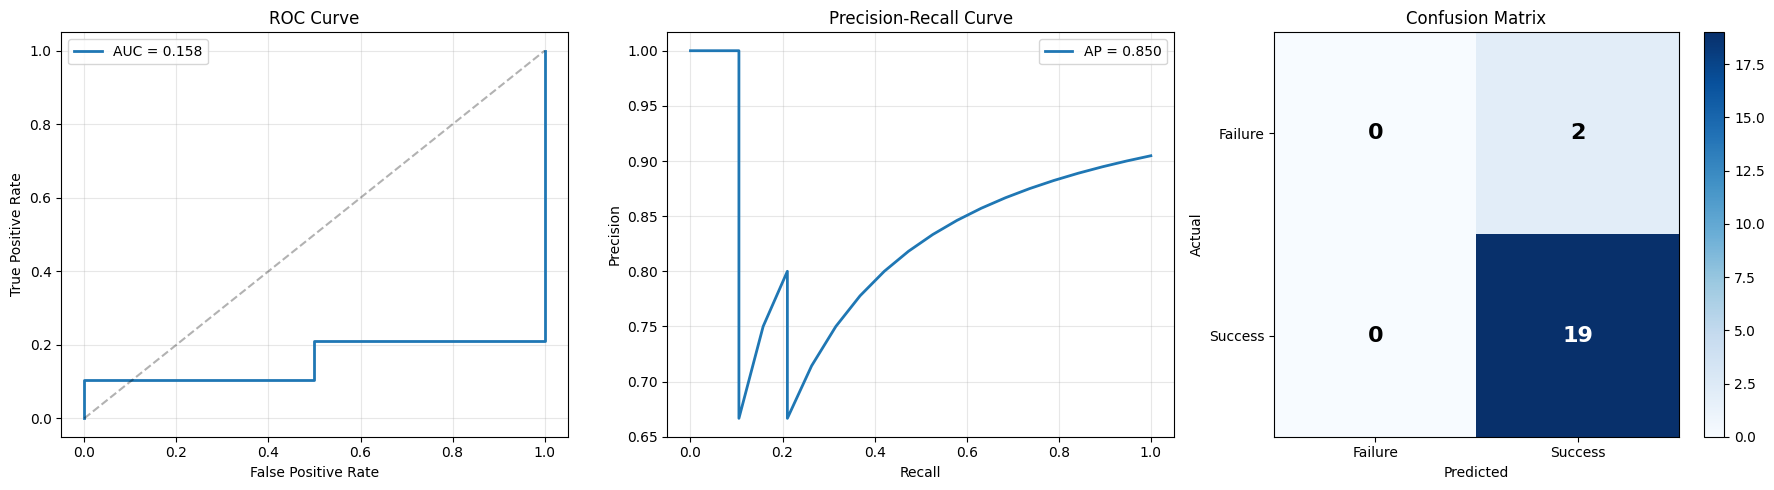

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC Curve
try:
    fpr, tpr, _ = roc_curve(labels, probs)
    auc_val = roc_auc_score(labels, probs)
    axes[0].plot(fpr, tpr, linewidth=2, label=f"AUC = {auc_val:.3f}")
    axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title("ROC Curve")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
except ValueError:
    axes[0].text(0.5, 0.5, "Insufficient data\nfor ROC", ha="center", va="center")

# Precision-Recall Curve
try:
    prec, rec, _ = precision_recall_curve(labels, probs)
    ap = average_precision_score(labels, probs)
    axes[1].plot(rec, prec, linewidth=2, label=f"AP = {ap:.3f}")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_title("Precision-Recall Curve")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
except ValueError:
    axes[1].text(0.5, 0.5, "Insufficient data\nfor PR", ha="center", va="center")

# Confusion Matrix
im = axes[2].imshow(cm, cmap="Blues", interpolation="nearest")
axes[2].set_title("Confusion Matrix")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")
axes[2].set_xticks([0, 1])
axes[2].set_yticks([0, 1])
axes[2].set_xticklabels(["Failure", "Success"])
axes[2].set_yticklabels(["Failure", "Success"])
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, str(cm[i][j]),
                     ha="center", va="center",
                     color="white" if cm[i][j] > cm.max() / 2 else "black",
                     fontsize=16, fontweight="bold")
plt.colorbar(im, ax=axes[2])

plt.tight_layout()
plt.savefig(MODEL_DIR / "evaluation_plots.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. CDSS Predictions

Generate per-patient predictions with **confidence scores** and **risk levels** for all 205 patients using full M0–M12 data. The attention weights reveal which treatment months the model focuses on most.

Since the model was trained on progressive partial sequences, these confidence scores are well-calibrated — the model has learned what each month's data contributes to the prediction.

In [24]:
def generate_cdss_predictions(model, X_temporal_all, X_static_all, df,
                              up_to_month=12):
    """
    Generate per-patient CDSS predictions with confidence scores.
    Uses data up to `up_to_month` (default: full M0–M12).
    """
    model.eval()
    n = len(df)

    # Prepare temporal data — zero-pad months beyond up_to_month
    x_t = np.zeros_like(X_temporal_all)
    x_t[:, : up_to_month + 1, :] = X_temporal_all[:, : up_to_month + 1, :]
    seq_lens = np.full(n, up_to_month + 1, dtype=np.int64)

    X_t = torch.FloatTensor(x_t).to(DEVICE)
    X_s = torch.FloatTensor(X_static_all).to(DEVICE)
    S = torch.LongTensor(seq_lens).to(DEVICE)

    with torch.no_grad():
        logits, attn_weights = model(X_t, X_s, seq_lens=S)
        probs = torch.sigmoid(logits).cpu().numpy()
        attn_weights = attn_weights.cpu().numpy()

    results = []
    for i in range(n):
        prob_success = float(probs[i])
        prob_failure = 1.0 - prob_success
        predicted_class = "Success" if prob_success >= 0.5 else "Failure"
        confidence = max(prob_success, prob_failure) * 100

        # Risk level for CDSS
        if prob_failure >= 0.7:
            risk_level = "HIGH RISK"
        elif prob_failure >= 0.4:
            risk_level = "MODERATE RISK"
        else:
            risk_level = "LOW RISK"

        # Most attended month (only among valid months)
        valid_attn = attn_weights[i, : up_to_month + 1]
        most_attended = int(np.argmax(valid_attn))

        results.append({
            "patient_idx": i,
            "treatment_regimen": df.iloc[i].get("treatment_regimen", "N/A"),
            "actual_outcome": df.iloc[i]["outcome"],
            "predicted_outcome": predicted_class,
            "prob_success": round(prob_success, 4),
            "prob_failure": round(prob_failure, 4),
            "confidence_pct": round(confidence, 2),
            "risk_level": risk_level,
            "months_used": f"M0–M{up_to_month}",
            "most_attended_month": f"M{most_attended}",
        })

    return pd.DataFrame(results)

# Generate predictions for all patients (full data)
df = pd.read_csv(DATA_DIR / "cleaned_combined_dataset.csv")
predictions_df = generate_cdss_predictions(model, X_temporal, X_static, df)
predictions_df.to_csv(MODEL_DIR / "predictions.csv", index=False)

print(f"Predictions saved to models/predictions.csv")
print(f"\nRisk Level Distribution:")
print(predictions_df["risk_level"].value_counts())
print(f"\nSample predictions:")
predictions_df.head(10)

Predictions saved to models/predictions.csv

Risk Level Distribution:
risk_level
LOW RISK     185
HIGH RISK     20
Name: count, dtype: int64

Sample predictions:


,patient_idx,treatment_regimen,actual_outcome,predicted_outcome,prob_success,prob_failure,confidence_pct,risk_level,months_used,most_attended_month
0,0,Regimen 1,Died,Failure,0.0304,0.9696,96.96,HIGH RISK,M0–M12,M0
1,1,Regimen 1,Treatment Completed,Success,0.9998,0.0002,99.98,LOW RISK,M0–M12,M0
2,2,Regimen 1,Cured,Success,1.0000,0.0000,100.00,LOW RISK,M0–M12,M1
3,3,Regimen 1,Treatment Completed,Success,1.0000,0.0000,100.00,LOW RISK,M0–M12,M0
4,4,Regimen 1,Treatment Completed,Success,1.0000,0.0000,100.00,LOW RISK,M0–M12,M0
5,5,Regimen 1,Treatment Completed,Success,1.0000,0.0000,100.00,LOW RISK,M0–M12,M0
6,6,Regimen 1,Treatment Completed,Success,0.9964,0.0036,99.64,LOW RISK,M0–M12,M0
7,7,Regimen 1,Treatment Completed,Success,1.0000,0.0000,100.00,LOW RISK,M0–M12,M0
8,8,Regimen 1,Treatment Completed,Success,0.9997,0.0003,99.97,LOW RISK,M0–M12,M0
9,9,Regimen 1,Treatment Completed,Success,1.0000,0.0000,100.00,LOW RISK,M0–M12,M0


## 7. CDSS Early Warning — Predict at Any Month

The model was **trained on progressive partial sequences** (M0 only, M0–M1, M0–M2, ..., M0–M12), so predicting at any month is now a first-class capability — not a hack with zero-padding the model has never seen.

This shows how confidence evolves as more monthly data becomes available.

In [25]:
def predict_at_month(model, x_temporal_single, x_static_single, up_to_month):
    """
    CDSS helper: predict outcome using only months 0..up_to_month.
    The model was trained on this exact scenario (progressive sequences),
    so predictions are reliable at any month.
    """
    model.eval()
    x_t = np.zeros_like(x_temporal_single)
    x_t[: up_to_month + 1] = x_temporal_single[: up_to_month + 1]

    x_t_tensor = torch.FloatTensor(x_t).unsqueeze(0).to(DEVICE)
    x_s_tensor = torch.FloatTensor(x_static_single).unsqueeze(0).to(DEVICE)
    seq_len = torch.LongTensor([up_to_month + 1]).to(DEVICE)

    with torch.no_grad():
        logit, attn_w = model(x_t_tensor, x_s_tensor, seq_lens=seq_len)
        prob_success = torch.sigmoid(logit).item()

    return {
        "month": up_to_month,
        "prob_success": round(prob_success, 4),
        "prob_failure": round(1 - prob_success, 4),
        "confidence_pct": round(max(prob_success, 1 - prob_success) * 100, 2),
        "predicted_outcome": "Success" if prob_success >= 0.5 else "Failure",
    }

# Demo: Early prediction for Patient 0
print("CDSS DEMO — Progressive Early Warning for Patient 0")
print(f"Actual outcome: {df.iloc[0]['outcome']}")
print(f"Regimen: {df.iloc[0]['treatment_regimen']}")
print("=" * 65)
print("  (Model trained on partial sequences — these are native predictions)")
print()
for month in range(0, 13):
    result = predict_at_month(model, X_temporal[0], X_static[0], month)
    bar = "█" * int(result["prob_success"] * 30)
    print(f"  After M{month:>2d}: {result['predicted_outcome']:<8s}  "
          f"Confidence={result['confidence_pct']:>5.1f}%  "
          f"P(Success)={result['prob_success']:.3f}  {bar}")

CDSS DEMO — Progressive Early Warning for Patient 0
Actual outcome: Died
Regimen: Regimen 1
  (Model trained on partial sequences — these are native predictions)

  After M 0: Failure   Confidence= 97.2%  P(Success)=0.029  
  After M 1: Failure   Confidence= 93.8%  P(Success)=0.062  █
  After M 2: Failure   Confidence= 93.1%  P(Success)=0.069  ██
  After M 3: Failure   Confidence= 94.3%  P(Success)=0.057  █
  After M 4: Failure   Confidence= 95.6%  P(Success)=0.044  █
  After M 5: Failure   Confidence= 96.4%  P(Success)=0.036  █
  After M 6: Failure   Confidence= 96.9%  P(Success)=0.031  
  After M 7: Failure   Confidence= 97.1%  P(Success)=0.029  
  After M 8: Failure   Confidence= 97.1%  P(Success)=0.029  
  After M 9: Failure   Confidence= 97.1%  P(Success)=0.029  
  After M10: Failure   Confidence= 97.1%  P(Success)=0.029  
  After M11: Failure   Confidence= 97.0%  P(Success)=0.030  
  After M12: Failure   Confidence= 97.0%  P(Success)=0.030  


### Per-Month Prediction Accuracy (Temporal Evaluation)

Evaluate the model's prediction quality at each month (M0–M12) across all test patients. This demonstrates how prediction accuracy improves as more temporal data becomes available — the hallmark of a proper temporal model.

Per-month prediction performance on TEST patients:
month  accuracy   f1      auc  n_correct  n_total
   M0  0.904762 0.95 0.157895         19       21
   M1  0.904762 0.95 0.131579         19       21
   M2  0.904762 0.95 0.118421         19       21
   M3  0.904762 0.95 0.131579         19       21
   M4  0.904762 0.95 0.131579         19       21
   M5  0.904762 0.95 0.105263         19       21
   M6  0.904762 0.95 0.105263         19       21
   M7  0.904762 0.95 0.118421         19       21
   M8  0.904762 0.95 0.131579         19       21
   M9  0.904762 0.95 0.131579         19       21
  M10  0.904762 0.95 0.131579         19       21
  M11  0.904762 0.95 0.157895         19       21
  M12  0.904762 0.95 0.157895         19       21


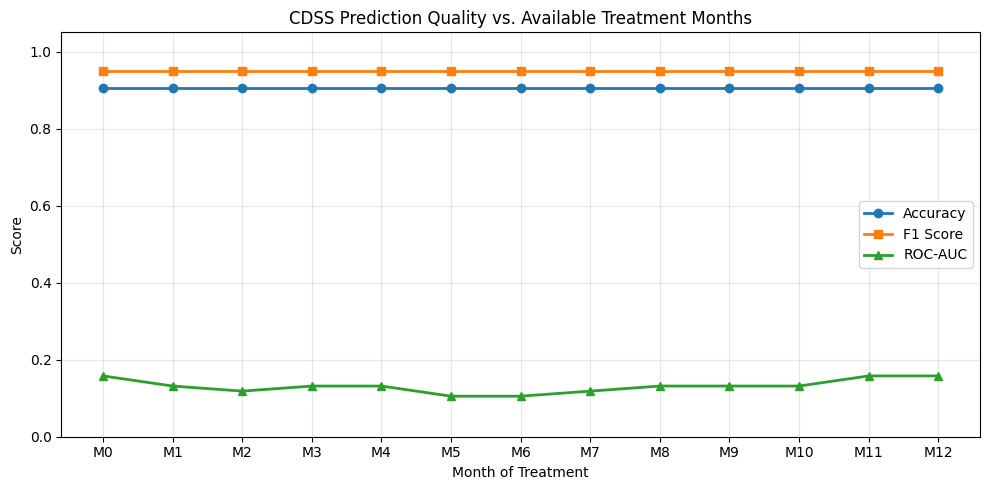

In [26]:
def evaluate_per_month(model, X_temporal_subset, X_static_subset, y_subset):
    """Evaluate model accuracy at each month (M0–M12) for a set of patients."""
    model.eval()
    month_metrics = []

    for month in range(13):
        n = len(y_subset)
        # Prepare truncated sequences
        x_t = np.zeros_like(X_temporal_subset)
        x_t[:, : month + 1, :] = X_temporal_subset[:, : month + 1, :]
        seq_lens = np.full(n, month + 1, dtype=np.int64)

        X_t = torch.FloatTensor(x_t).to(DEVICE)
        X_s = torch.FloatTensor(X_static_subset).to(DEVICE)
        S = torch.LongTensor(seq_lens).to(DEVICE)

        with torch.no_grad():
            logits, _ = model(X_t, X_s, seq_lens=S)
            probs = torch.sigmoid(logits).cpu().numpy()

        preds = (probs >= 0.5).astype(int)
        acc = accuracy_score(y_subset, preds)
        f1 = f1_score(y_subset, preds, zero_division=0)
        try:
            auc = roc_auc_score(y_subset, probs)
        except ValueError:
            auc = float("nan")

        month_metrics.append({
            "month": f"M{month}",
            "accuracy": acc,
            "f1": f1,
            "auc": auc,
            "n_correct": int((preds == y_subset).sum()),
            "n_total": n,
        })

    return pd.DataFrame(month_metrics)

# Evaluate on test patients at each month
test_temporal = X_temporal[test_idx]
test_static = X_static[test_idx]
test_labels = y[test_idx]

monthly_perf = evaluate_per_month(model, test_temporal, test_static, test_labels)
print("Per-month prediction performance on TEST patients:")
print(monthly_perf.to_string(index=False))

# Plot per-month metrics
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(13), monthly_perf["accuracy"], "o-", label="Accuracy", linewidth=2)
ax.plot(range(13), monthly_perf["f1"], "s-", label="F1 Score", linewidth=2)
ax.plot(range(13), monthly_perf["auc"], "^-", label="ROC-AUC", linewidth=2)
ax.set_xlabel("Month of Treatment")
ax.set_ylabel("Score")
ax.set_title("CDSS Prediction Quality vs. Available Treatment Months")
ax.set_xticks(range(13))
ax.set_xticklabels([f"M{i}" for i in range(13)])
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig(MODEL_DIR / "per_month_performance.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Save Model Config & Evaluation Report

In [27]:
# Save model config for reproducibility and reloading
config = {
    "temporal_features": int(X_temporal.shape[2]),
    "static_features": int(X_static.shape[1]),
    "lstm_hidden": 64,
    "lstm_layers": 2,
    "dropout": 0.3,
    "n_patients": int(len(y)),
    "train_patients": int(len(train_idx)),
    "val_patients": int(len(val_idx)),
    "test_patients": int(len(test_idx)),
    "train_samples": f"{len(train_idx)} patients × 13 months = {len(train_idx) * 13}",
    "split": "70/20/10 (patient-level, then progressive expansion)",
    "training_mode": "progressive_temporal (one sample per patient per month)",
    "seed": SEED,
    "static_feature_names": static_names,
    "temporal_feature_names": [
        "cumulative_doses_taken", "height",
        "monthly_doses_taken", "monthly_missed_doses",
        "pct_adherence", "smear_tb_lamp", "weight", "xpert_mtb_rif",
    ],
}
with open(MODEL_DIR / "model_config.json", "w") as f:
    json.dump(config, f, indent=2)
print("✓ models/model_config.json")

# Save evaluation report
report_lines = [
    "TB-DOTS CAR CDSS — Evaluation Report (Progressive Temporal Training)",
    "=" * 65,
    f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}",
    f"Device: {DEVICE}",
    f"Dataset: {len(y)} patients, split 70/20/10 (patient-level)",
    f"Training mode: Progressive temporal — 13 samples/patient (M0..M12)",
    f"Model: Hybrid Bi-LSTM + Masked Attention + Static FC",
    "",
    "Test Set Metrics (full M0–M12 sequences):",
    "-" * 40,
]
for k, v in metrics.items():
    report_lines.append(f"  {k:<14s} : {v:.4f}")
report_lines.extend([
    "",
    "Confusion Matrix:",
    str(cm),
    "",
    classification_report(labels, preds,
                          target_names=["Failure", "Success"],
                          zero_division=0),
    "",
    "Per-Month Prediction Performance (Test Patients):",
    "-" * 40,
    monthly_perf.to_string(index=False),
])
with open(MODEL_DIR / "evaluation_report.txt", "w") as f:
    f.write("\n".join(report_lines))
print("✓ models/evaluation_report.txt")
print("✓ models/best_model.pt")
print("✓ models/predictions.csv")
print("✓ models/training_curves.png")
print("✓ models/evaluation_plots.png")
print("✓ models/per_month_performance.png")
print("\nAll outputs saved to models/")

✓ models/model_config.json
✓ models/evaluation_report.txt
✓ models/best_model.pt
✓ models/predictions.csv
✓ models/training_curves.png
✓ models/evaluation_plots.png
✓ models/per_month_performance.png

All outputs saved to models/
